In [18]:
import xarray as xr
import numpy as np
import os
home_path = '/gws/ssde/j25a/duicv/yuansun/'
lane_width = 3.5

# Default land surface data

In [2]:
ds_surf = xr.open_dataset(f'{home_path}dataset/inputdata/lnd/clm2/surfdata_esmf/ctsm5.3.0/surfdata_0.9x1.25_hist_2000_78pfts_c240908.nc')
ds_surf

<xarray.Dataset> Size: 2GB
Dimensions:                  (lsmlat: 192, lsmlon: 288, nlevsoi: 10,
                              numurbl: 3, numrad: 2, nlevurb: 10, nglcecp1: 11,
                              nglcec: 10, cft: 64, natpft: 15, time: 12,
                              lsmpft: 79)
Coordinates:
  * natpft                   (natpft) int32 60B 0 1 2 3 4 5 ... 9 10 11 12 13 14
  * cft                      (cft) int32 256B 15 16 17 18 19 ... 74 75 76 77 78
  * time                     (time) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: lsmlat, lsmlon, nlevsoi, numurbl, numrad,
                                nlevurb, nglcecp1, nglcec, lsmpft
Data variables: (12/82)
    LONGXY                   (lsmlat, lsmlon) float64 442kB ...
    LATIXY                   (lsmlat, lsmlon) float64 442kB ...
    mxsoil_color             int32 4B ...
    SOIL_COLOR               (lsmlat, lsmlon) int32 221kB ...
    PCT_SAND                 (nlevsoi, lsmlat, lsmlon) float32 2MB ...
    PCT_CLAY                 (nlevsoi, lsmlat, lsmlon) float32 2MB ...
    ...                       ...
    PCT_NAT_PFT              (natpft, lsmlat, lsmlon) float64 7MB ...
    PCT_CFT                  (cft, lsmlat, lsmlon) float64 28MB ...
    MONTHLY_LAI              (time, lsmpft, lsmlat, lsmlon) float64 419MB ...
    MONTHLY_SAI              (time, lsmpft, lsmlat, lsmlon) float64 419MB ...
    MONTHLY_HEIGHT_TOP       (time, lsmpft, lsmlat, lsmlon) float64 419MB ...
    MONTHLY_HEIGHT_BOT       (time, lsmpft, lsmlat, lsmlon) float64 419MB ...
Attributes: (12/46)
    Conventions:                              NCAR-CESM
    History_Log:                              created on: 09-08-24 19:37:49
    Source:                                   Community Land Model: CLM5
    Version:                                  branch_tags/ctsm5.3.n03_ctsm5.2...
    Dataset_Version:                          5.3
    Logname:                                  slevis
    ...                                       ...
    lai_raw_data_file_name:                   mksrf_landuse_ctsm53_pftlai_CLI...
    soil_color_raw_data_file_name:            mksrf_landuse_ctsm53_soilcolor_...
    soil_texture_mapunit_raw_data_file_name:  mksrf_soil_mapunits_5x5min_WISE...
    soil_texture_lookup_raw_data_file_name:   mksrf_soil_lookup.10level.WISE....
    fmax_raw_data_file_name:                  mksrf_fmax_0.125x0.125_c200220.nc
    VOC_EF_raw_data_file_name:                mksrf_vocef_0.5x0.5_simyr2000.c...

In [3]:
surf_pct_urban = ds_surf['PCT_URBAN']
ds_surf_urban_mask = surf_pct_urban.where(surf_pct_urban > 0)
ds_surf_urban_mask

<xarray.DataArray 'PCT_URBAN' (numurbl: 3, lsmlat: 192, lsmlon: 288)> Size: 1MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Dimensions without coordinates: numurbl, lsmlat, lsmlon
Attributes:
    long_name:  percent urban for each density type
    units:      unitless

In [16]:
road_width_surf = (ds_surf['HT_ROOF'] / ds_surf['CANYON_HWR']).where(ds_surf_urban_mask.notnull())
improad_width_surf = road_width_surf * (1 - ds_surf['WTROAD_PERV'])
improad_width_surf['LATIXY'] = ds_surf['LATIXY']
improad_width_surf['LONGXY'] = ds_surf['LONGXY']
#improad_width_surf.to_netcdf('data_for_figure/default_impervious_road_width.nc')
improad_width_surf

<xarray.DataArray (numurbl: 3, lsmlat: 192, lsmlon: 288)> Size: 1MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
    LATIXY   (lsmlat, lsmlon) float64 442kB ...
    LONGXY   (lsmlat, lsmlon) float64 442kB ...
Dimensions without coordinates: numurbl, lsmlat, lsmlon

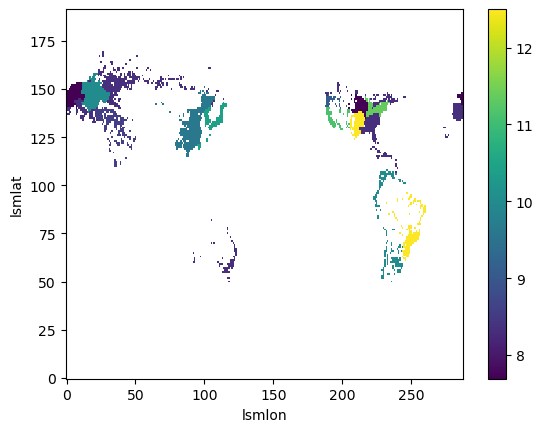

In [7]:
improad_width_surf[2].where(improad_width_surf[2]>=7).plot()

In [22]:
#land_mask_surf = improad_width_surf[0].where(improad_width_surf[0] > 0)
#nlane = xr.DataArray(np.zeros_like(improad_width), coords=improad_width.coords)
# divided = ratio of road width to lane width
divided_surf = improad_width_surf / lane_width

# Initialize nlane with zeros, same shape and coordinates as improad_width
nlane_surf = xr.DataArray(np.zeros_like(improad_width_surf), coords=improad_width_surf.coords)

# Rule 1: very narrow road → 0 lanes
nlane_surf = xr.where(divided_surf < 0.5, 0, nlane_surf)

# Rule 2: narrow but possible one-lane road → 1 lane
nlane_surf = xr.where((divided_surf >= 0.5) & (divided_surf < 2), 1, nlane_surf)

# Rule 3: wider roads → even number of lanes
lane_count_surf = (improad_width_surf // lane_width).astype(int)
even_lane_count_surf = xr.where(lane_count_surf % 2 == 1, lane_count_surf - 1, lane_count_surf)

nlane_surf = xr.where(divided_surf >= 2, even_lane_count_surf, nlane_surf)
nlane_surf = nlane_surf.where(~np.isnan(divided_surf))
nlane_surf['LATIXY'] = ds_surf['LATIXY']
nlane_surf['LONGXY'] = ds_surf['LONGXY']
nlane_surf.name = 'num_lanes'
surf_output_file = 'data_for_figure/default_num_lanes.nc'
if os.path.exists(surf_output_file):
    os.remove(surf_output_file)
nlane_surf.to_netcdf(surf_output_file)    
nlane_surf

/home/users/yuan1239/.conda/envs/conda_env/lib/python3.9/site-packages/xarray/core/duck_array_ops.py:239: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


<xarray.DataArray 'num_lanes' (numurbl: 3, lsmlat: 192, lsmlon: 288)> Size: 1MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
    LATIXY   (lsmlat, lsmlon) float64 442kB ...
    LONGXY   (lsmlat, lsmlon) float64 442kB ...
Dimensions without coordinates: numurbl, lsmlat, lsmlon

# U-Surf

In [4]:
ds_usurf = xr.open_dataset(f'{home_path}dataset/U-Surf/CESM_1deg_surfdata_v1.1/surfdata_0.9x1.25_hist_2015_78pfts_USurf_prop_v1.1.nc')
ds_usurf

<xarray.Dataset> Size: 2GB
Dimensions:                  (lsmlat: 192, lsmlon: 288, nlevsoi: 10,
                              numurbl: 3, numrad: 2, nlevurb: 10, nglcecp1: 11,
                              nglcec: 10, cft: 64, natpft: 15, time: 12,
                              lsmpft: 79)
Coordinates:
  * natpft                   (natpft) int32 60B 0 1 2 3 4 5 ... 9 10 11 12 13 14
  * cft                      (cft) int32 256B 15 16 17 18 19 ... 74 75 76 77 78
  * time                     (time) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: lsmlat, lsmlon, nlevsoi, numurbl, numrad,
                                nlevurb, nglcecp1, nglcec, lsmpft
Data variables: (12/82)
    LONGXY                   (lsmlat, lsmlon) float64 442kB ...
    LATIXY                   (lsmlat, lsmlon) float64 442kB ...
    mxsoil_color             int32 4B ...
    SOIL_COLOR               (lsmlat, lsmlon) int32 221kB ...
    PCT_SAND                 (nlevsoi, lsmlat, lsmlon) float32 2MB ...
    PCT_CLAY                 (nlevsoi, lsmlat, lsmlon) float32 2MB ...
    ...                       ...
    PCT_NAT_PFT              (natpft, lsmlat, lsmlon) float64 7MB ...
    PCT_CFT                  (cft, lsmlat, lsmlon) float64 28MB ...
    MONTHLY_LAI              (time, lsmpft, lsmlat, lsmlon) float64 419MB ...
    MONTHLY_SAI              (time, lsmpft, lsmlat, lsmlon) float64 419MB ...
    MONTHLY_HEIGHT_TOP       (time, lsmpft, lsmlat, lsmlon) float64 419MB ...
    MONTHLY_HEIGHT_BOT       (time, lsmpft, lsmlat, lsmlon) float64 419MB ...
Attributes: (12/45)
    Conventions:                              NCAR-CESM
    History_Log:                              created on: 01-23-25 18:48:22
    Source:                                   Community Land Model: CLM5
    Version:                                  alpha-ctsm5.2.mksrf.25_ctsm5.1....
    Logname:                                  yifanc17
    Host:                                     derecho3
    ...                                       ...
    lai_raw_data_file_name:                   mksrf_pftlaihgt_ctsm52_histLUH2...
    soil_color_raw_data_file_name:            mksrf_soilcolor_ctsm52_histLUH2...
    soil_texture_mapunit_raw_data_file_name:  mksrf_soil_mapunits_5x5min_WISE...
    soil_texture_lookup_raw_data_file_name:   mksrf_soil_lookup.10level.WISE....
    fmax_raw_data_file_name:                  mksrf_fmax_0.125x0.125_c200220.nc
    VOC_EF_raw_data_file_name:                mksrf_vocef_0.5x0.5_simyr2000.c...

In [5]:
usurf_pct_urban = ds_usurf['PCT_URBAN']
ds_usurf_urban_mask = usurf_pct_urban.where(usurf_pct_urban > 0)

In [8]:
road_width_usurf = (ds_usurf['HT_ROOF'] / ds_usurf['CANYON_HWR']).where(ds_usurf_urban_mask.notnull())
improad_width_usurf = road_width_usurf * (1 - ds_usurf['WTROAD_PERV'])
improad_width_usurf

<xarray.DataArray (numurbl: 3, lsmlat: 192, lsmlon: 288)> Size: 1MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Dimensions without coordinates: numurbl, lsmlat, lsmlon

In [21]:
#land_mask_usurf = improad_width_usurf[0].where(improad_width_usurf[0] > 0)
divided_usurf = improad_width_usurf / lane_width
nlane_usurf = xr.DataArray(np.zeros_like(improad_width_usurf), coords=improad_width_usurf.coords)
nlane_usurf = xr.where(divided_usurf < 0.5, 0, nlane_usurf)
nlane_usurf = xr.where((divided_usurf >= 0.5) & (divided_usurf < 2), 1, nlane_usurf)
lane_count_usurf = (improad_width_usurf // lane_width).astype(int)
even_lane_count_usurf = xr.where(lane_count_usurf % 2 == 1, lane_count_usurf - 1, lane_count_usurf)
nlane_usurf = xr.where(divided_usurf >= 2, even_lane_count_usurf, nlane_usurf)
nlane_usurf = nlane_usurf.where(~np.isnan(divided_usurf))
nlane_usurf['LATIXY'] = ds_surf['LATIXY']
nlane_usurf['LONGXY'] = ds_surf['LONGXY']
nlane_usurf.name = 'num_lanes'
usurf_output_file = 'data_for_figure/usurf_num_lanes.nc'
if os.path.exists(usurf_output_file):
    os.remove(usurf_output_file)
nlane_usurf.to_netcdf(usurf_output_file) 
nlane_usurf

/home/users/yuan1239/.conda/envs/conda_env/lib/python3.9/site-packages/xarray/core/duck_array_ops.py:239: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


<xarray.DataArray 'num_lanes' (numurbl: 3, lsmlat: 192, lsmlon: 288)> Size: 1MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
    LATIXY   (lsmlat, lsmlon) float64 442kB ...
    LONGXY   (lsmlat, lsmlon) float64 442kB ...
Dimensions without coordinates: numurbl, lsmlat, lsmlon

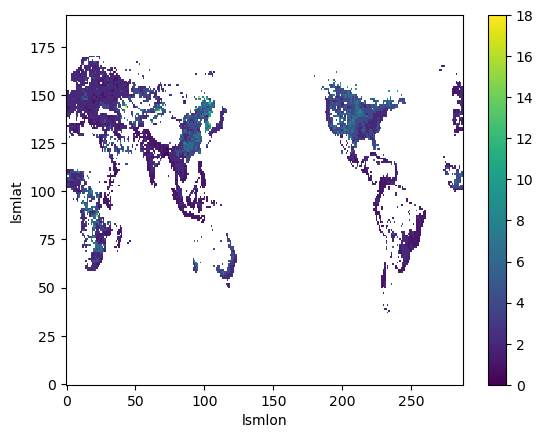

In [14]:
nlane_usurf[2].plot()